<span style="color:gray; font-size:smaller;">Written by Salil Deshpande</span>

Once you have created a MotifCompendium, you will want to easily visualize the motifs and motif clusters in your MotifCompendium. This tutorial will focus on the various visualization tools that MotifCompendium offers to help visualize, plot, and interact with your MotifCompendium.

Let's get started!

We will begin by importing the packages that we will need.

In [1]:
import gdown
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import MotifCompendium
import MotifCompendium.utils.analysis as utils_analysis
import MotifCompendium.utils.plotting as utils_plotting
import MotifCompendium.utils.visualization as utils_visualization

**Please ignore the cell below.**

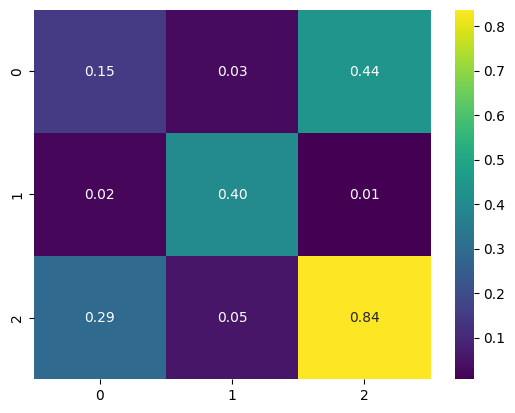

In [2]:
sns.heatmap(np.random.rand(3, 3), annot=True, fmt=".2f", cmap="viridis")
plt.show()

None of the visualization or plotting utilities in MotifCompendium make use of GPUs, so, for the purposes of this tutorial, we will not be setting `use_gpu` (it is `False` by default). However, visualization can benefit from CPU parallelization, so we will be setting a high `max_cpus=16` value. If you do not have access to 16 CPUs, MotifCompendium will adapt to the number of CPUs you have access to.

In [3]:
MotifCompendium.set_compute_options(max_cpus=16)

We will also download all the data that we will need for this tutorial.

In [4]:
cardiomyocyte_file_id = "1iAeA2dczPsDEhDp3d4qsVt0oBtU9X07R"
cardiomyocyte_file_url = f"https://drive.google.com/uc?id={cardiomyocyte_file_id}"
cardiomyocyte_output_file = "tutorial_data/cardiomyocyte_modisco_output.h5"
gdown.download(cardiomyocyte_file_url, cardiomyocyte_output_file, quiet=False)

endothelial_file_id = "1Na2-QIa5davufwc_R4Awa87MQf6zBhR4"
endothelial_file_url = f"https://drive.google.com/uc?id={endothelial_file_id}"
endothelial_output_file = "tutorial_data/endothelial_modisco_output.h5"
gdown.download(endothelial_file_url, endothelial_output_file, quiet=False)

h13_file_id = "1Zrpxjo89LtRBVzOIHmg9HpnX0cEGGmUB"
h13_file_url = f"https://drive.google.com/uc?id={h13_file_id}"
h13_pfm_file = "tutorial_data/H13CORE_pfms.txt"
gdown.download(h13_file_url, h13_pfm_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iAeA2dczPsDEhDp3d4qsVt0oBtU9X07R
From (redirected): https://drive.google.com/uc?id=1iAeA2dczPsDEhDp3d4qsVt0oBtU9X07R&confirm=t&uuid=675fb259-19d3-456a-af3c-d581b9af717f
To: /users/salil512/experiments/MotifCompendium/tutorials/tutorial_data/cardiomyocyte_modisco_output.h5
100%|██████████| 484M/484M [00:04<00:00, 111MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=1Na2-QIa5davufwc_R4Awa87MQf6zBhR4
From (redirected): https://drive.google.com/uc?id=1Na2-QIa5davufwc_R4Awa87MQf6zBhR4&confirm=t&uuid=d29b0c9a-8304-4b65-84be-74743968a474
To: /users/salil512/experiments/MotifCompendium/tutorials/tutorial_data/endothelial_modisco_output.h5
100%|██████████| 241M/241M [00:02<00:00, 112MB/s]  
Downloading...
From: https://drive.google.com/uc?id=1Zrpxjo89LtRBVzOIHmg9HpnX0cEGGmUB
To: /users/salil512/experiments/MotifCompendium/tutorials/tutorial_data/H13CORE_pfms.txt
100%|██████████| 1.62M/1.62M [00:00<00:00, 17.5MB

'tutorial_data/H13CORE_pfms.txt'

# 1 - Motif Collection

We will begin by recapping the introduction to visualizing a motif collection that was given in [Tutorial 1](1_basic_usage.ipynb).

First, we will build and cluster a MotifCompendium.

In [5]:
modisco_dict = {
    "cardiomyocyte": "tutorial_data/cardiomyocyte_modisco_output.h5",
    "endothelial": "tutorial_data/endothelial_modisco_output.h5"
}
mc = MotifCompendium.build_from_modisco(modisco_dict)
mc.cluster(similarity_threshold=0.96)
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,1
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,18
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,12
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,11
...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,8
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,7
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,6
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,76


One of the visualizations of a MotifCompendium that one may want to perform is to view all the motifs in their MotifCompendium. This can be done with the `.motif_collection_html()` method. This method takes in two arguments, the path to which the save the output .html file, and the metadata column to group motifs by.

Below, let us run the method.

In [6]:
mc.motif_collection_html("tutorial_outputs/motif_collection.html", "cluster")

The [motif collection](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/motif_collection.html) is saved as a .html file, which can be opened in any internet browser as well as many code editors. What you will see is a 2-column visualization of all motifs in the calling MotifCompendium. In both columns, you will see boxes with a light grey background that say "Cluster X" at the top and have multiple motif logos inside them. Each box represents one of the groups specified by the `group_by` argument. In this case, we set `group_by="cluster"` so each box represents one motif cluster. The titles of the boxes indicate which cluster is being shown. Within each box, the top logo has a green background and is the average logo of all the group constituents. Below that, each logo represents one motif in the group. At the top left of each logo, there is text that says the name of that motif. The name is taken from the `"name"` column of the MotifCompendium; this column is expected to exist and an error will be thrown if no such column exists. Within each group, all motifs are automatically aligned. This is because alignment information stored in the MotifCompendium is used to automatically align motifs in a motif collection visualization.

**The .html file produced by calling `.motif_collection_html()` is a fully standalone file.** That is, it can be moved and shared and will still work; the images being displayed are not being drawn from external image files but are instead embedded within the file itself.

`.motif_collection_html()` can take the optional boolean argument, `average_motif`. By default, it is `True`. However, if it is set to `False`, the green average motifs shown at the top of each group will not be shown.

The `.motif_collection_html()` method calls the `motif_collection_html()` function from the visualization submodule in the back end. If you would like to create your own extremely customized motif html, you can do that by calling the `motif_collection_html()` function from visualization submodule. The inputs to the underlying function are very different, however. The underlying function takes two arguments, `motif_groups` and `html_out`. `html_out` is the path to which the save the output html file. `motif_groups` is a dictionary from a string representing group names to a list of LogoPlottingInput objects. The LogoPlottingInput class is defined in `utils/plotting.py` and contains information about a motif that needs to be plotted.

The LogoPlottingInput constructor takes in a 2D `np.ndarray` of shape `(L, 4)` that specifies which motif should be plotted. Additionally, the constructor can take in the arguments `revcomp`, `pos`, `name`, and `bgcolor`. `revcomp` is a boolean that is `False` by default and specifies whether or not the motif logo should be reverse complemented. `pos` specifies the horizontal shift of the motif and is 0 by default. `name` is the name of the motif that is displayed at the top left of the motif logo in the collection. `bgcolor`, which is set to `"white"` by default, is the background color of the logo plot and should be any value that can be interpreted as a color by Matplotlib.

Below is an example of creating a random customized motif collection.

In [7]:
motif_groups = dict()
for i in range(4):
    motif_groups[f"Group {i}"] = []
    for j in range(2*(i+1)):
        motif_groups[f"Group {i}"].append(
            utils_plotting.LogoPlottingInput(
                motif=np.random.rand(10, 4),  # Random motif of length 10
                name=f"Motif {i}-{j}",
                bgcolor="lightskyblue"
            )
        )

utils_visualization.motif_collection_html(motif_groups, "tutorial_outputs/random_custom_motif_collection.html")

In our [custom motif collection](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/random_custom_motif_collection.html), we were able to visualize motifs with a blue background. For more information on the LogoPlottingInput class, please refer to the class definition in `utils/plotting.py`.

# 2 - Fast Logo Plotting

With an extremely large MotifCompendium, plotting all the motifs can take extremely long. Even with CPU parallelism, the default plotting, which is done by Logomaker can be too slow. To speed this up, MotifCompendium offers a `fast_plotting` option, which uses custom plotting code to speed up logo plotting by up to 66%. The `fast_plotting` option can be set in the `set_compute_options()` function.

First, we will time it without using fast plotting.

In [8]:
%time mc.motif_collection_html("tutorial_outputs/motif_collection.html", "cluster")

CPU times: user 227 ms, sys: 235 ms, total: 462 ms
Wall time: 14.8 s


And now, we will try it with fast plotting.

In [9]:
MotifCompendium.set_compute_options(fast_plotting=True)
%time mc.motif_collection_html("tutorial_outputs/motif_collection_fastplotting.html", "cluster")

CPU times: user 191 ms, sys: 228 ms, total: 419 ms
Wall time: 9.32 s


It is ~1.5x faster!

In the [fast plotting collection](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/motif_collection_fastplotting.html), we can see how motifs are drawn with a blockier style during fast plotting. Depending on how large your MotifCompendium is, you may want to consider fast plotting as an option.

Fast plotting will be turned off for the rest of this tutorial.

In [10]:
MotifCompendium.set_compute_options(fast_plotting=False)

# 3 - Summary Table

The other visualization you can do of your MotifCompendium is to create a summary table that shows the motifs in the MotifCompendium as well as per-motif information stored in the metadata. This can be done by calling the `.summary_table_html()` method of a MotifCompendium. This method takes one required argument, `html_out`, which specifies the path to which the save the output .html file.

Below, let us run the method.

In [11]:
mc.summary_table_html("tutorial_outputs/motif_summary_table.html")

The [summary table](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/motif_summary_table.html) is saved as an interactive .html file. The summary table is a spreadsheet-like table where each row represents a motif in the MotifCompendium and the columns contain information about each motif. The top two rows of the table are light gray and serve as headers for the table. The first row has titles for each column. You will also notice blue up arrow and down arrow buttons in the cells of the first row that correspond to columns that don't contain images. These buttons allow you to sort the table dynamically. In the second row, you will see text boxes in the cells that correspond to columns that don't contain images. When you type into a text box, it will filter the table to only show motifs whose metadata in that column match the text written in the text box.

**The .html file produced by calling `.summary_table_html()` is a fully standalone file.** That is, it can be moved and shared and will still work; the images being displayed are not being drawn from external image files but are instead embedded within the file itself.

The first three columns of a summary table are always the same. The first column, called index, matches the metadata's index and can be used to match the summary table up with the calling MotifCompendium. The second and third column are always the forward and reverse logos of the motifs.

By default, the remaining columns are all the columns in the metadata of the calling MotifCompendium. However, which columns are displayed can be customized. The `.summary_table_html()` method can optionally take in a list of columns to display. These columns can either be columns in the metadata or saved images. Use the `.columns()` and `.images()` methods to see what columns and saved images are available.

In [12]:
# View columns/saved images
print(f"available columns: {mc.columns()}")
print(f"available saved images: {mc.images()}")

available columns: ['name', 'num_seqlets', 'model', 'posneg', 'avg_contrib', 'avg_dist_from_summit', 'cluster']
available saved images: ['logo (fwd)', 'logo (rev)']


We will perform a quick automatic motif annotation to label our motifs, which will add the columns `h13_score0` and `h13_name0`, as well as the saved image `h13_logo0`. Then, we will display them in a summary table. The columns to be displayed in the summary table can be input as the optional second argument to the method. The order in which columns and saved images are arranged in the argument will be the order in which they are displayed in the summary table.

In [13]:
utils_analysis.assign_label_from_pfms(
    mc,
    "tutorial_data/H13CORE_pfms.txt",
    "h13")
mc.summary_table_html("tutorial_outputs/motif_summary_table_h13.html", ["name", "num_seqlets", "model", "posneg", "h13_logo0", "h13_score0", "h13_name0"])

We can now see that our [summary table](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/motif_summary_table_h13.html) now displays information about motif annotation as well as images of the closest match to our PFM database.

For very large MotifCompendium with thousands of motifs, motif collections and summary tables can become too large to easily generate, render, and visualize. Because of this, for large MotifCompendium, it is recommended to only create a summary table for cluster-averaged MotifCompendium and not for the original MotifCompendium. And instead of creating a motif collection visualization for the whole MotifCompendium, it is recommended to create a motif collection for each cluster as its constituents become relevant for inspection. For example, you could follow the following code pattern.

In [14]:
# Create a cluster-averaged MotifCompendium just as in Tutorial 1
mc_avg = mc.cluster_averages("cluster")
mc_avg.add_motif_strings()
# Create a summary table just as in Tutorial 1
mc_avg.summary_table_html("tutorial_outputs/cluster_summary_table.html")
# Create a motif collection of a particular cluster
mc[mc["cluster"] == 0].motif_collection_html("tutorial_outputs/cluster_0_motif_collection.html", "cluster")

Above, after creating a [summary table of motif clusters](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/cluster_summary_table.html), we decided we were interested in the motifs that made up Cluster 0. So, we created a [motif collection just for the motifs in cluster 0](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/cluster_0_motif_collection.html).

# 4 - Using Summary Tables For Interactive Manual Motif Annotation

Annotating motifs and motif clusters is a critical step in motif analysis. MotifCompendium offers some utilities to perform automatic motif analysis. See [Tutorial 5](5_motif_annotation.ipynb) for more details on how this is done. However, while it would be ideal for this process to entirely automatic, it rarely is able to be and often needs manual annotation or review.

Summary tables can help with this process of manual annotation and review of motifs and motif clusters. Summary tables can be made editable by providing the optional `editable=True` flag when creating a summary table.

In [15]:
mc.summary_table_html("tutorial_outputs/editable_motif_summary_table_h13.html", ["name", "num_seqlets", "model", "posneg", "h13_logo0", "h13_score0", "h13_name0"], editable=True)

In the [editable summary table](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/editable_motif_summary_table_h13.html), every text cell in the summary table is editable. Editing a cell fill it with an orange background so that you know it has been edited. Reverting a cell to its original text will make the orange background disappear.

With an editable summary table, you can review and edit annotations or other motif information. And, whatever edits you make to the summary table can be imported back into the source MotifCompendium to update it. Changes you make to the summary table are not automatically reflected in the source MotifCompendium, though. If you want to import the edits you have made, the first thing you need to do is save your changes.

A very common workflow is to:

1) Create a summary table .html file and then open it through a web browser.
2) Make edits in-browser.
3) Save the edited web page. When you make edits in-browser, those changes are not saved to the underlying file that is being served. Instead, you must save (ctrl+s) a local copy of the file (save as `Web Page, complete`). Then, you will have some local, edited version of the summary table. Any edits you made should still show up when viewing your local copy of the summary table.
4) Copy the saved, edited file to a location that you can access programatically.
5) Import the file back into the source MotifCompendium. To do so, call the `.update_from_summary_table()` method and provide it with the path to the saved, edited summary table. This will import all the changes you had made in-browser into the MotifCompendium object itself.

In the example below, `tutorial_outputs/editable_motif_summary_table_h13.html` was edited to change the annotation of the first motif. The edited summary table `tutorial_outputs/edited_motif_summary_table_h13.html` will be re-uploaded into the MotifCompendium.

In [16]:
mc.update_from_summary_table("tutorial_outputs/edited_motif_summary_table_h13.html")
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,h13_score0,h13_name0
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,0,0.973554,CUSTOM
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,1,0.893059,NFIX.H13CORE.0.SM.B
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,18,0.941498,TBX5.H13CORE.1.P.B
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,12,0.979117,GATA1.H13CORE.0.P.B
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,11,0.965150,ELK4.H13CORE.0.PSM.A
...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,8,0.989322,JUNB.H13CORE.0.PM.A
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,7,0.983499,NFYA.H13CORE.0.P.B
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,6,0.950249,GMEB1.H13CORE.2.SM.B
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,76,0.853628,FLI1.H13CORE.1.P.B


In the [edited summary table](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/editable_motif_summary_table_h13.html), notice how the value of `h13_name0` for the first motif is now `CUSTOM` instead of `CTCF.H13CORE.0.P.B`. We successfully updated our MotifCompendium through manual annotation!

Before performing manual annotation, it can be helpful to add a couple of columns to help keep track of the manual annotation process. It can be helpful to add columns called `looked_at` and `notes` in which you keep track of whether or not you have looked at a particular motif and any other notes you may have about the motif, respectively. You can filter the `looked_at` column of the summary table by typing `F` into the text box; that way, once you are finished looking at a motif, you can edit the cell from `F` to `T` and the filter will remove it from the motifs you are looking at.

In [17]:
mc["looked_at"] = "F"
mc["notes"] = ""
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,h13_score0,h13_name0,looked_at,notes
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,0,0.973554,CUSTOM,F,
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,1,0.893059,NFIX.H13CORE.0.SM.B,F,
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,18,0.941498,TBX5.H13CORE.1.P.B,F,
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,12,0.979117,GATA1.H13CORE.0.P.B,F,
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,11,0.965150,ELK4.H13CORE.0.PSM.A,F,
...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,8,0.989322,JUNB.H13CORE.0.PM.A,F,
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,7,0.983499,NFYA.H13CORE.0.P.B,F,
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,6,0.950249,GMEB1.H13CORE.2.SM.B,F,
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,76,0.853628,FLI1.H13CORE.1.P.B,F,


When editing MotifCompendium in this manner, you can add or remove columns from the metadata between creating the original summary table and updating the MotifCompendium with the summary table. However, it is crucial that you do not sort or re-order the MotifCompendium between creating the original summary table and updating the MotifComepndium with the summary table. If you do, you run the risk of having the summary table not lining up with the MotifCompendium and incorrectly updating the MotifCompendium; this type of error happens silently and is difficult to catch, so it is best to simply avoid this situation.

# 5 - Heatmap

Another way to visualize a MotifCompendium is to create a heatmap of the similarity matrix. This can help you visualize motif clustering and similarity structure. This can be done by calling the `.heatmap()` method of your MotifCompendium. To display the heatmap, add the `show=True` argument. If you want to save it to file, you can also provide the `save_loc` argument, which should be the path to where to save the heatmap image.

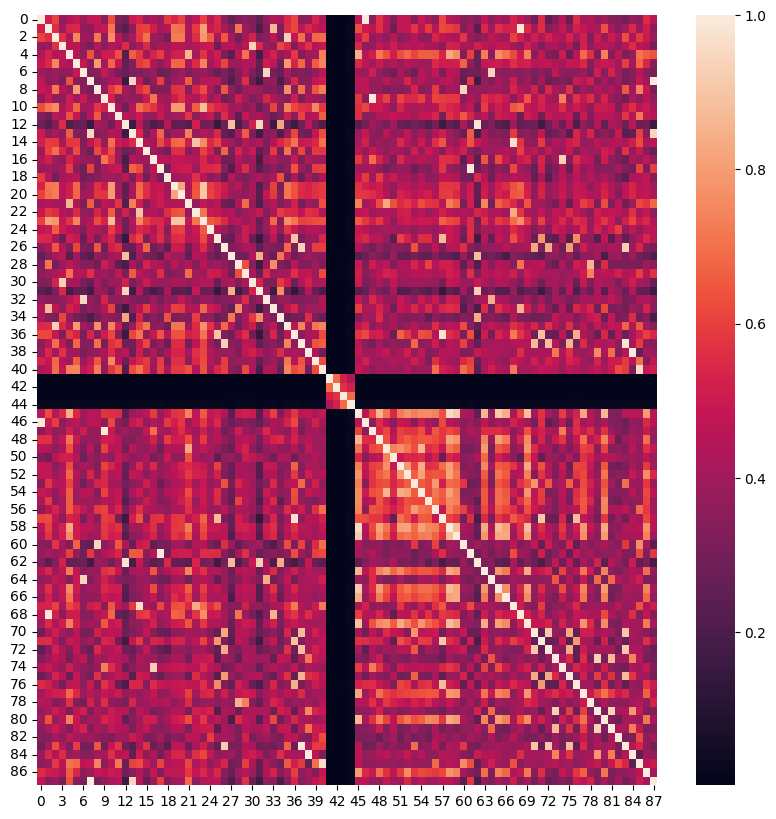

In [18]:
mc.heatmap(show=True, save_loc="tutorial_outputs/similarity_heatmap.png")

The similarity matrix of a MotifCompendium will be relatively disordered. But, if you first sort the MotifCompendium by cluster order, then you will be able to see a block-diagonal structure which shows that your motifs have been clustered properly.

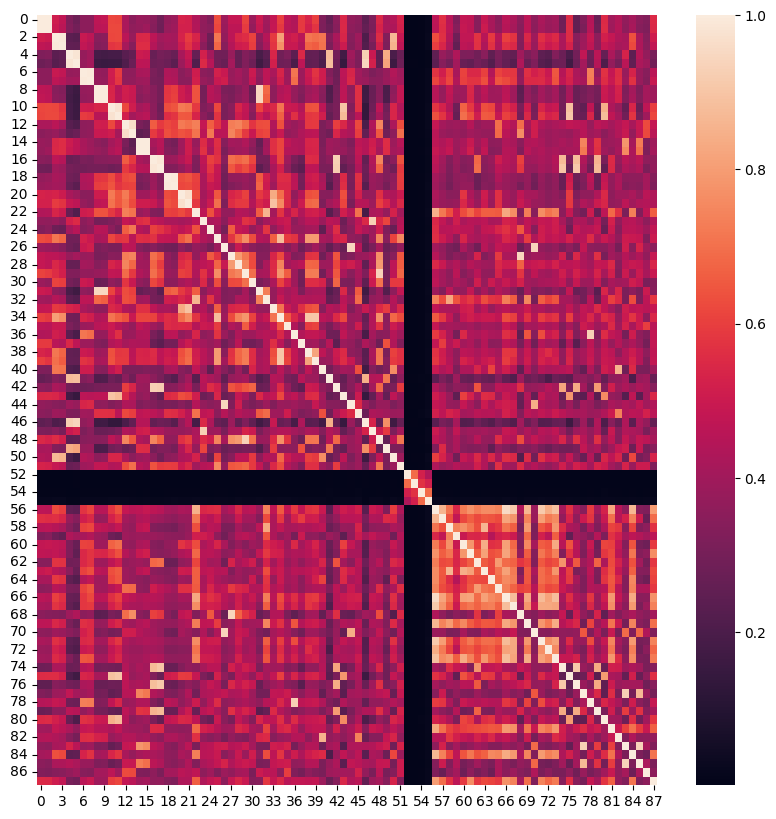

In [19]:
mc_sorted = mc.sort(by="cluster")
mc_sorted.heatmap(show=True, save_loc="tutorial_outputs/similarity_heatmap_sorted.png")

This is even more clear when you visualize the heatmap but threshold it by the similarity threshold we clustered on. You can do this by setting the optional argument `similarity_threshold`. It should be set to any floating point number between 0 and 1. Similarities below the `similarity_threshold` will not be shown.

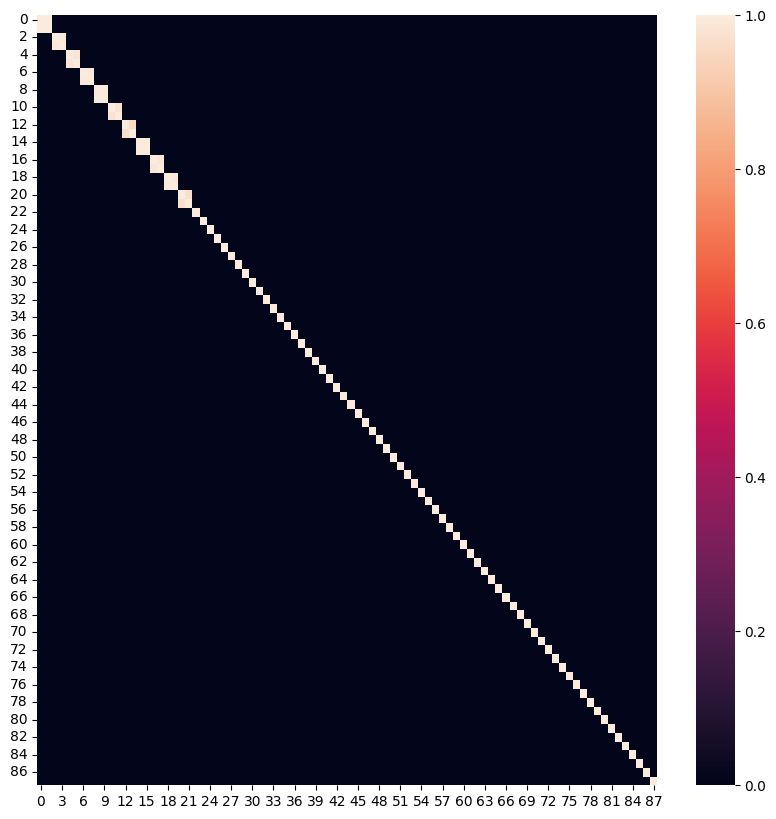

In [20]:
mc_sorted.heatmap(similarity_threshold=0.96, show=True, save_loc="tutorial_outputs/similarity_heatmap_sorted_thresholded.png")

You can show the motif names on the axes by setting `label=True`, and you can show the values in the cells by setting `annot=True`. For visual clarity, these are best done when inspecting small subsets of the data, like when you are looking at particular clusters of the data. Below, we will visualize the similarity matrix of just the motifs in clusters 0 and 1.

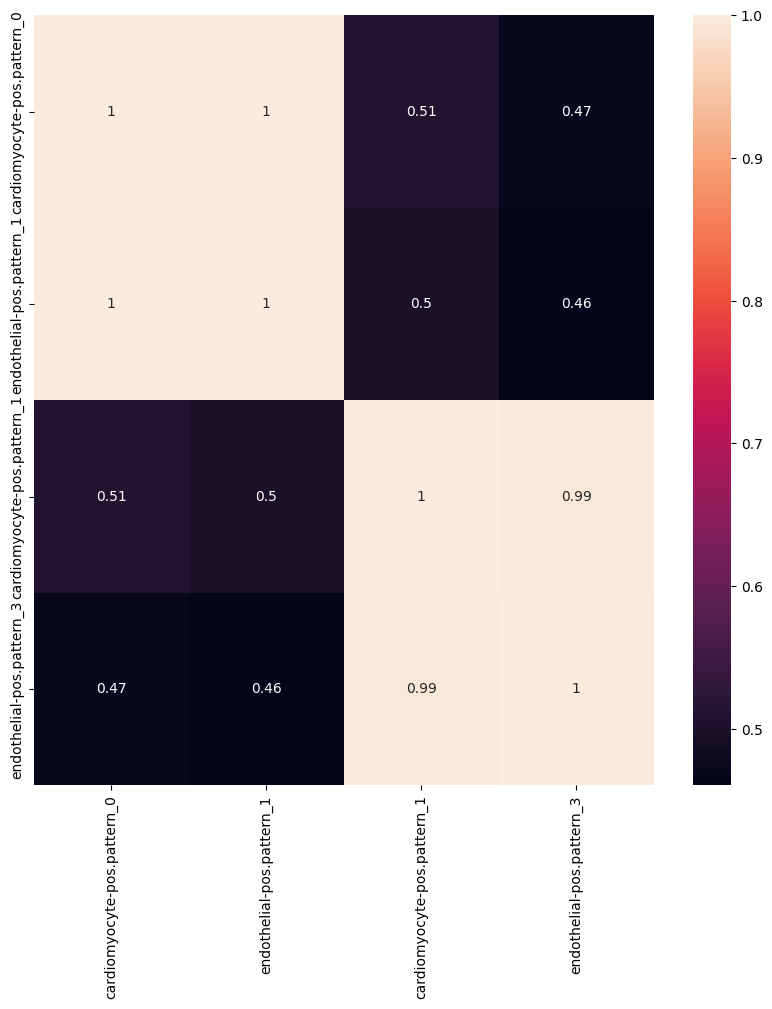

In [21]:
mc[mc["cluster"].isin([0, 1])].sort("cluster").heatmap(show=True, label=True, annot=True, save_loc="tutorial_outputs/similarity_heatmap_clusters_0-1.png")

# 6 - Plotting motifs yourself

The MotifCompendium package also offers utilities to plot motif logos. To plot a single motif, call the `plot_motif()` function in `MotifCompendium.utils.plotting`. It takes in a `(L, 4)` `np.ndarray` representing a motif. To display the motif, add the `show=True` argument. If you want to save it to file, you can also provide the `save_loc` argument, which should be the path to where to save the logo.

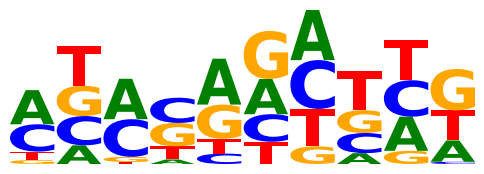

In [22]:
utils_plotting.plot_motif(np.random.rand(10, 4), show=True, save_loc="tutorial_outputs/random_motif_logo.png")

If you want to plot many motifs at once, you can use the `plot_motif_stack()` function. THis function takes in a `(N, L, 4)` stack of motifs that will all be plotted in a column.

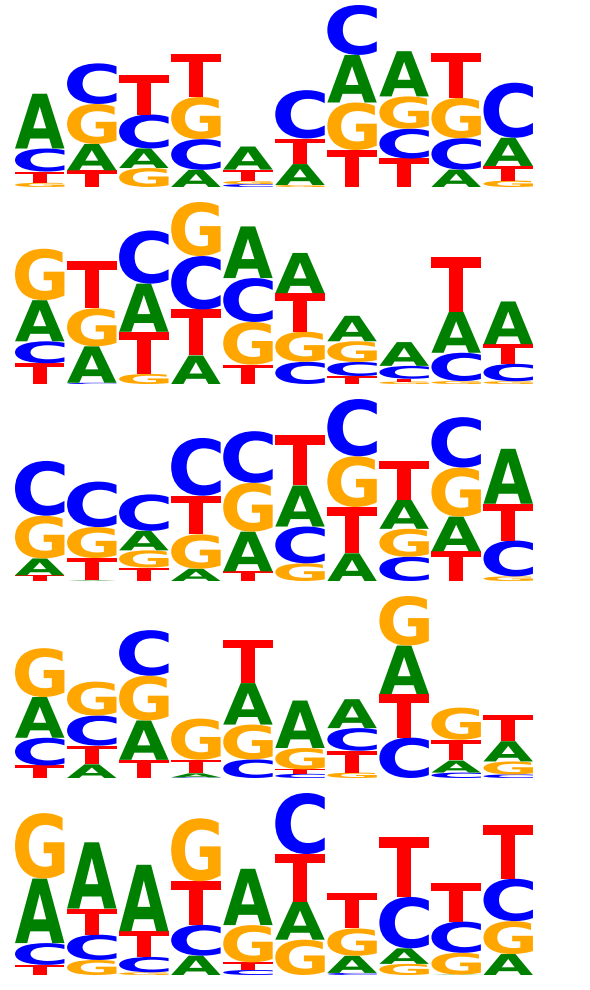

In [23]:
utils_plotting.plot_motif_stack(np.random.rand(5, 10, 4), show=True, save_loc="tutorial_outputs/random_motif_stack_logo.png")

If you want to plot a single motif from a MotifCompendium, you can call the `plot_motif()` function and pass in a motif from the `.get_standard_motif_stack()` method.

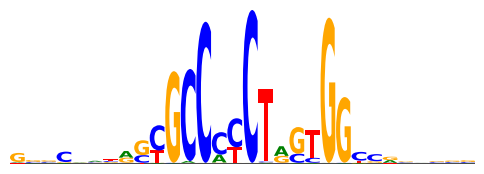

In [24]:
utils_plotting.plot_motif(mc.get_standard_motif_stack()[0], show=True, save_loc="tutorial_outputs/compendium_motif_logo.png")

Similarly, if you want to plot many motifs from a MotifCompendium, you can call the `plot_motif_stack()` function and pass in motifs from the `.get_standard_motif_stack()` method.

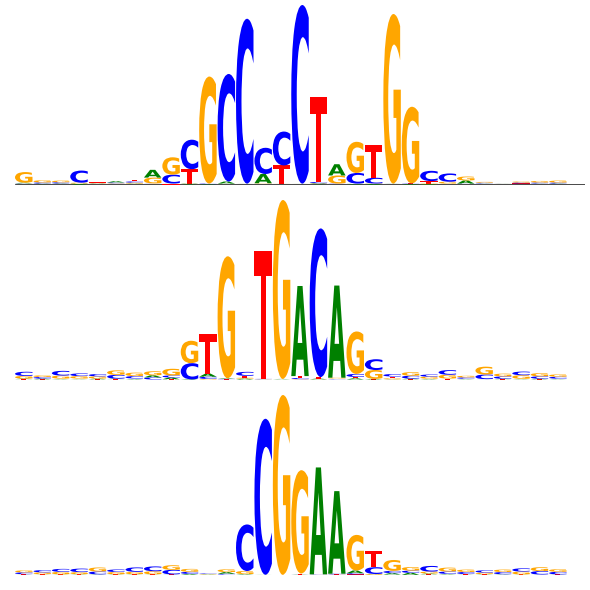

In [25]:
utils_plotting.plot_motif_stack(mc.get_standard_motif_stack()[[0, 2, 4]], show=True, save_loc="tutorial_outputs/compendium_motif_stack_logo.png")

# 7 - Conclusion

This tutorial describes the various ways in which you can visualize your MotifCompendium. In particular, motif collections and summary tables serve as the most natural way to visualize and interact with the motifs in your MotifCompendium. Editable summary tables can even be generated to help with manual annotation and editing of a MotifCompendium. And, utilities in the `utils/plotting.py` module can be used on their own to plot motifs directly.

Thank you so much for trying out MotifCompendium!